[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


--- VADER (Lexicon-Based) Performance ---
Accuracy: 0.8801
              precision    recall  f1-score   support

           0       0.68      0.46      0.55       873
           1       0.90      0.96      0.93      4673

    accuracy                           0.88      5546
   macro avg       0.79      0.71      0.74      5546
weighted avg       0.87      0.88      0.87      5546


--- Logistic Regression (ML-Based) Performance ---
Accuracy: 0.9028
              precision    recall  f1-score   support

           0       0.86      0.46      0.60       873
           1       0.91      0.99      0.94      4673

    accuracy                           0.90      5546
   macro avg       0.88      0.72      0.77      5546
weighted avg       0.90      0.90      0.89      5546



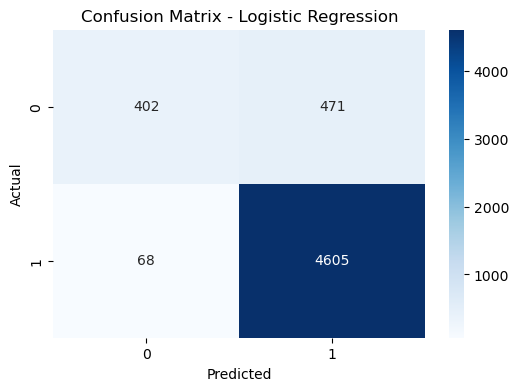

In [1]:
# ==========================================================
# Name: Ammar Wildan bin Mustafar
# ID: SW01083734
# Name: Muhammad Adam Zharfan bin Mohd Khairul Hisham
# ID: SW01083748
# Project: Sentiment Analysis of Amazon Fine Food Reviews
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

nltk.download('vader_lexicon')
nltk.download('stopwords')

# 1. DATA PREPROCESSING
file_path = "Reviews.csv"
df = pd.read_csv(file_path, encoding='latin1')

# Dropping "inappropriate" or non-contributory columns
# We keep 'Score' for labeling and 'Text' for analysis 
cols_to_drop = ['Id', 'ProductId', 'UserId', 'ProfileName', 
                'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Time', 'Summary']
df = df.drop(columns=cols_to_drop)
# Sampling to handle the large review volume efficiently 
df = df.sample(30000, random_state=42).dropna()

# Map Score to Binary Sentiment: 1 (Positive: 4-5) and 0 (Negative: 1-2)
# Neutral reviews (Score 3) are removed to sharpen classification
df = df[df['Score'] != 3]
df['Sentiment'] = df['Score'].apply(lambda s: 1 if s > 3 else 0)

def clean_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)  # Remove HTML tags
    text = re.sub(r'[^a-z\s]', '', text) # Remove punctuation and numbers
    return text

df['CleanedText'] = df['Text'].apply(clean_text)

# 2. FEATURE EXTRACTION
X = df['CleanedText']
y = df['Sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# 3. MODEL SELECTION & TRAINING

#Lexicon-Based (VADER)
sid = SentimentIntensityAnalyzer()

def get_vader_sentiment(text):
    score = sid.polarity_scores(text)
    return 1 if score['compound'] >= 0 else 0

vader_preds = X_test.apply(get_vader_sentiment)

# Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)
lr_preds = lr_model.predict(X_test_tfidf)

# 4. MODEL EVALUATION
print("--- VADER (Lexicon-Based) Performance ---")
print(f"Accuracy: {accuracy_score(y_test, vader_preds):.4f}")
print(classification_report(y_test, vader_preds))

print("\n--- Logistic Regression (ML-Based) Performance ---")
print(f"Accuracy: {accuracy_score(y_test, lr_preds):.4f}")
print(classification_report(y_test, lr_preds))

# Confusion Matrix Visualization
cm = confusion_matrix(y_test, lr_preds)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [2]:
# 5. DISCUSSION
#DISCUSSION ON STRENGTHS AND WEAKNESSES:
#The Lexicon-based model (VADER) is highly advantageous because it requires no training data and is computationally inexpensive. It performs well on social media-style text where emojis and intensifiers are common. However, it struggles with domain-specific sarcasm and language, for example,'bitter' can be positive for coffee but negative for a snack. 
#The Machine Learning model (Logistic Regression with TF-IDF) generally outperforms VADER in accuracy because it learns context-specific word associations from the Amazon dataset itself. Its strength lies in capturing nuances specific to food reviews. The primary weakness of the ML approach is its dependency on a large, labeled dataset and the requirement of a preprocessing/training pipeline, making it less portable than a pre-built lexicon.

In [3]:
df.to_csv("cleaned_amazon_reviews.csv", index=False)